# Import the Data file

In [36]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("../data/gdp_data.csv")
df.head()



,country,year,gdp_growth,growth_change,gdp_rolling_avg,cumulative_growth,growth_category
0,ABW,2003,1.110505,NaN,1.110505,1.110505,Low Growth
1,ABW,2006,1.127411,0.016906,1.118958,2.237916,Low Growth
2,ABW,2009,-11.677741,-12.805152,-3.146608,-9.439825,Negative Growth
3,ABW,2020,-23.897990,-12.220249,-11.482773,-33.337815,Negative Growth
4,AFE,1994,1.919654,NaN,1.919654,1.919654,Low Growth


## 1. TOP 10 Economies by Latest GDP Growth

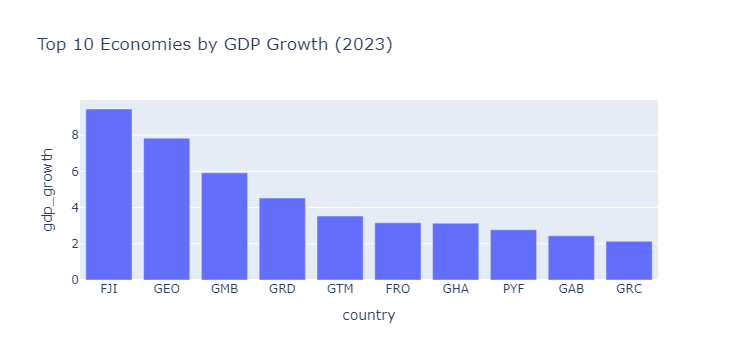

In [41]:
df_latest = df[df["year"]==df["year"].max()]

top10 = df_latest.sort_values("gdp_growth",ascending=False).head(10)

fig = px.bar(top10,x="country",y="gdp_growth",title=f"Top 10 Economies by GDP Growth ({df["year"].max()})")
fig.show()

## 2. Bottom 10 Economies (Economic Decline Insight)

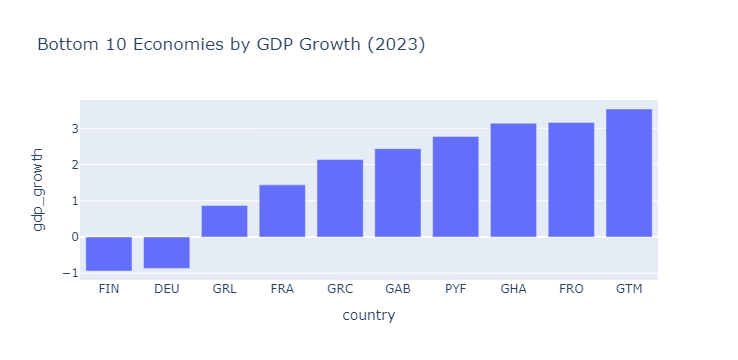

In [45]:
bottom10 = df_latest.sort_values("gdp_growth").head(10)

fig = px.bar(bottom10,x="country",y="gdp_growth",title=f"Bottom 10 Economies by GDP Growth ({df["year"].max()})")
fig.show()

## 3. GDP Growth Trend (Country Wise)

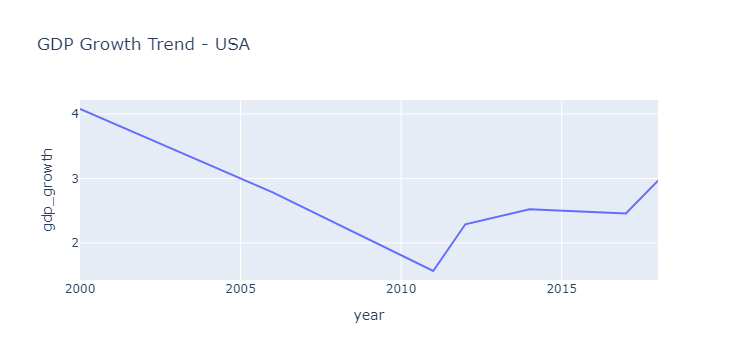

In [55]:
country = "USA"
country_df = df[df["country"]==country]

px.line(country_df,x="year",y="gdp_growth",title=f"GDP Growth Trend - {country}").show()

## 4. Rolling Average Trend (Smooth Curve)

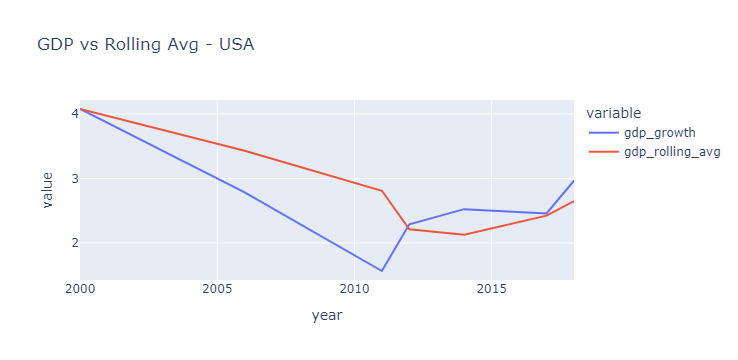

In [58]:
px.line(country_df,x="year",y=["gdp_growth","gdp_rolling_avg"],title=f"GDP vs Rolling Avg - {country}").show()

## 5. Global Distribution of Growth

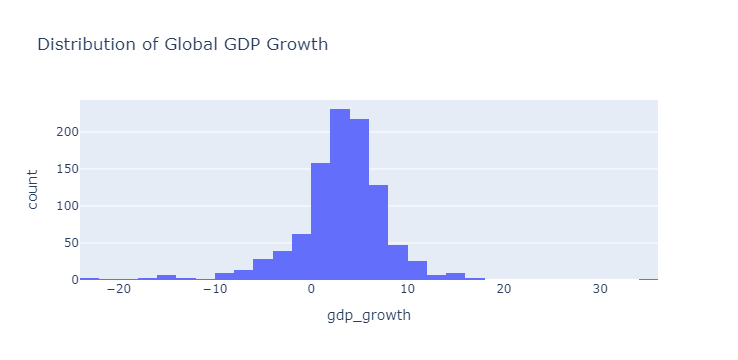

In [62]:
px.histogram(df,x="gdp_growth",nbins=50,title="Distribution of Global GDP Growth").show()

## 6. Growth Category Analysis

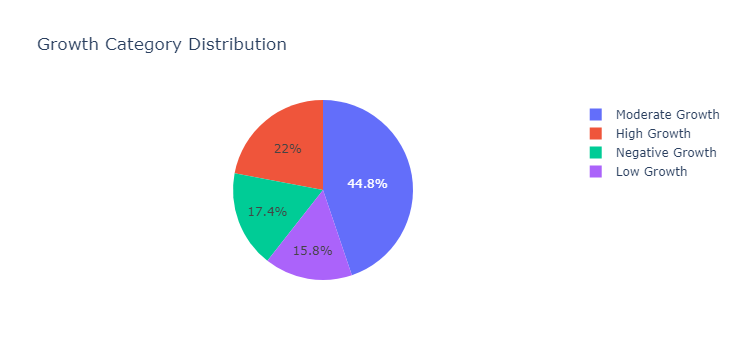

In [68]:
category_count = df["growth_category"].value_counts()
px.pie(values=category_count.values,names=category_count.index,title="Growth Category Distribution").show()

## 7. Country Overall Growth

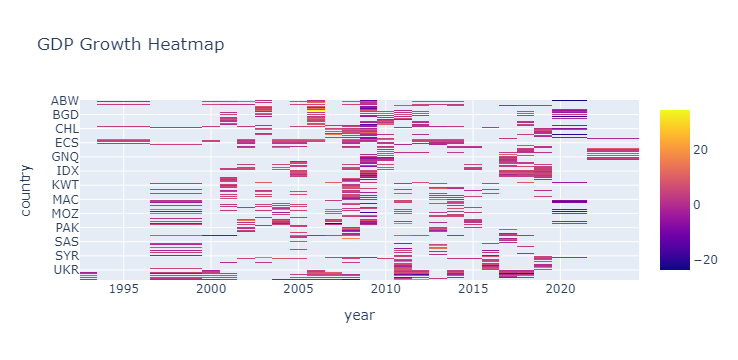

In [79]:
pivot = df.pivot_table(
    index = "country",
    columns="year",
    values="gdp_growth")
px.imshow(pivot,aspect="auto",title="GDP Growth Heatmap").show()

## 8. Most Volatile Economies

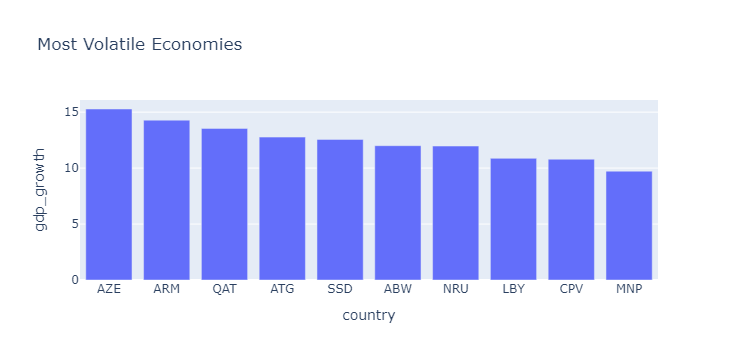

In [82]:
volatility = df.groupby("country")["gdp_growth"].std().reset_index()

top_volatile = volatility.sort_values("gdp_growth",ascending=False).head(10)

px.bar(top_volatile,x="country",y="gdp_growth",title="Most Volatile Economies").show()

## Key Insights

1. Most countries fall under Moderate Growth category.
2. Some countries show high volatility indicating unstable economies.
3. Negative growth spikes observed during global crises (e.g., 2008, 2020).
4. Rolling averages reveal long-term economic stability trends.